In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import scipy.optimize
import scipy.stats
from scipy.integrate import quad
import scipy.stats as stats
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.io.shapereader as shpreader
from sklearn import tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.model_selection import KFold
import copy
import calendar
from optimise_GDD_fctns import * #Phenology_set, run_GDD_and_get_RMSE, run_GDD_and_get_RMSE_derivs, plot_profiles_at_minimum, get_station_locations, put_ERA5_in_array

#import seaborn as sns

import plotting
import dataset_fctns
import modelling_fctns
import seaborn as sns
#from dwd_phenpy import Phenology_set

#import openeo
#import ee
## Trigger the authentication flow.
#ee.Authenticate()#(auth_mode='localhost')
# Initialize the library.
#ee.Initialize(project='ee-martinparker637')

c:\Users\wlwc1989\Documents\Phenology_Test_Notebooks\phenology_dwd\optimisation_experiments\optimise_GDD_fctns.py:34: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  station_data = pd.read_csv("https://opendata.dwd.de/climate_environment/CDC/help/PH_Beschreibung_Phaenologie_Stationen_Jahresmelder.txt",sep = ";\s+|;\t+|;\s+\t+|;\t+\s+|;|\s+;|\t+;|\s+\t+;|\t+\s+;", encoding='cp1252', on_bad_lines='skip')


In [2]:
def train_test_by_year(ds, test_years):
    obs_for_testing = ds['year'].isin(test_years)
    train_ds = ds[~obs_for_testing]
    test_ds = ds[obs_for_testing]
    return train_ds, test_ds

In [3]:
def plot_from_comparison_array(comparison_array, title_extra='', method='scatter', savename = False, phase_list = ['beginning of flowering'], exclude_unfinished = False, growing_period_length = 300, col = 'blue'):
    if method == 'both':
        fig, axs = plt.subplots(len(phase_list), 2, figsize = (10, len(phase_list)*5))
    else:
        fig, axs = plt.subplots(1, len(phase_list), figsize = (len(phase_list)*5, 5))
    for phase_index, phase in enumerate(phase_list):
        number_unfinished = (comparison_array[f'modelled time to {phase}'] >= growing_period_length).sum()
        number_total = len(comparison_array)
        print(f'{number_unfinished} stations out of {number_total} did not reach the end of phase \'{phase}\'')
        if exclude_unfinished:
            comparison_array = comparison_array[comparison_array[f'modelled time to {phase}'] < growing_period_length].dropna()
        #comparison_array[f'observed time to {phase}'] = comparison_array[f'observed time to {phase}'].dt.days
        if len(phase_list) == 1:
            ax = axs
        else:
            ax = axs[phase_index]
        if method == 'regression':
            #x_estimator=np.mean,
            #minval = min(comparison_array[f'observed time to {phase}'].min(), comparison_array[f'modelled time to {phase}'].min()) - 1
            #maxval = max(comparison_array[f'observed time to {phase}'].max(), comparison_array[f'modelled time to {phase}'].max()) + 1
            minval = min(comparison_array[f'observed time to {phase}'].quantile(0.05), comparison_array[f'modelled time to {phase}'].quantile(0.05)) - 1
            maxval = max(comparison_array[f'observed time to {phase}'].quantile(0.95), comparison_array[f'modelled time to {phase}'].quantile(0.95)) + 1
            sns.regplot(x=f'modelled time to {phase}', y=f'observed time to {phase}', data=comparison_array, ax=axs,
                        scatter_kws={'alpha':0.5, 's':4},  x_bins=np.arange(minval - 5, maxval + 5, 2.5), color=col)
            axs.plot([minval, maxval], [minval, maxval], linestyle='--', color='k', lw=1, scalex=False, scaley=False)
            axs.set_xlim(minval, maxval)
            axs.set_ylim(minval, maxval)
            axs.set_title(f'Modelled and observed time to {phase}\n{title_extra}')
        elif method == 'errors':
            comparison_array['error'] = comparison_array[f'observed time to {phase}'] - comparison_array[f'modelled time to {phase}']
            sns.regplot(x=f'modelled time to {phase}', y='error', data=comparison_array, ax=axs,
                        scatter_kws={'alpha':0.5, 's':4},  x_bins=np.arange(30, 200, 5))
            axs.set_title(f'Comparison of fitted values and residuals {phase}\n{title_extra}')
        elif method == 'histogram':
            sns.histplot(x=f'modelled time to {phase}', data = comparison_array, ax=ax, label = 'modelled days to anthesis',
                        stat = 'density')
            sns.histplot(x=f'observed time to {phase}', data = comparison_array, ax=ax, label= 'observed days to anthesis',
                        stat = 'density')
            sns.set(font_scale=1.5)
            axs.set_title(f'Comparison of GDD modelled and observed time to\n{phase} {title_extra}')
            ax.set_xlabel('Days after planting')
            #ax.plot([minval, maxval], [minval, maxval], linestyle = '--', color='k')
            fig.legend(bbox_to_anchor = (1.2, 0.9))
            rsquared = r2_score(comparison_array[f'observed time to {phase}'], comparison_array[f'modelled time to {phase}'])
            print(f'R^2 value for model: {rsquared}')
            bias = comparison_array[f'observed time to {phase}'].mean() - comparison_array[f'modelled time to {phase}'].mean()
            variance_modelled = comparison_array[f'modelled time to {phase}'].var()
            print(f'Bias: {bias**2}\nVariance of modelled values: {variance_modelled}')
        elif method == 'both':
            ax = axs[0]
            minval = min(comparison_array[f'observed time to {phase}'].quantile(0.05), comparison_array[f'modelled time to {phase}'].quantile(0.05)) - 1
            maxval = max(comparison_array[f'observed time to {phase}'].quantile(0.95), comparison_array[f'modelled time to {phase}'].quantile(0.95)) + 1
            sns.regplot(x=f'modelled time to {phase}', y=f'observed time to {phase}', data=comparison_array, ax=ax,
                        scatter_kws={'alpha':0.5, 's':4},  x_bins=np.arange(minval - 5, maxval + 5, 5))
            ax.plot([minval, maxval], [minval, maxval], linestyle='--', color='k', lw=1, scalex=False, scaley=False)
            ax.set_xlim(minval, maxval)
            ax.set_ylim(minval, maxval)
            
            ax = axs[1]
            sns.histplot(x=f'modelled time to {phase}', data = comparison_array, ax=ax, label = 'modelled days to anthesis',
                        stat = 'density')
            sns.histplot(x=f'observed time to {phase}', data = comparison_array, ax=ax, label= 'observed days to anthesis',
                        stat = 'density')
            sns.set(font_scale=1.5)
            fig.suptitle(f'Comparison of GDD modelled and observed time to\n{phase} {title_extra}')
            ax.set_xlabel('Days after planting', fontsize = 18)
            ax.set_ylabel('Density', fontsize = 18)
            #ax.plot([minval, maxval], [minval, maxval], linestyle = '--', color='k')
            fig.legend(bbox_to_anchor = (1.2, 0.8))
            fig.tight_layout()
    rsquared = r2_score(comparison_array[f'observed time to {phase}'], comparison_array[f'modelled time to {phase}'])
    print(f'R^2 value for model: {rsquared}')
    bias = comparison_array[f'observed time to {phase}'].mean() - comparison_array[f'modelled time to {phase}'].mean()
    variance_modelled = comparison_array[f'modelled time to {phase}'].var()
    print(f'Bias: {bias**2} (sign {np.sign(bias)})\nVariance of modelled values: {variance_modelled}')
    if savename != False:
        fig.savefig(f'plots/{savename}', bbox_inches='tight')

In [4]:
def local_opt(x1s, train, test, error_fctn = run_GDD_and_get_RMSE, lower_bounds = [0.05, 4, 20, 20, 35], upper_bounds = [1, 12, 35, 35, 60], #ds
              great_threshold = 13, response_type = 'Trapezoid', phase_list = ['yellow ripeness'],
              method = 'trust-constr', modified_cost = False, thresholds = [100], growing_period_length = 185,
              maxiter = 50, split = True, CCNN_split = False, test_size = 0.5, random_state=1, itr = 0.5, bias_term = False):
    #if split:
    #    train, test = train_test_split(ds, test_size=test_size, random_state = random_state)
    #    #train_indices = pd.read_csv('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\results_for_comparing\\model_output\\temp_CCNN_training.csv')
    #elif CCNN_split:
    #    test_indices = pd.read_csv('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\results_for_comparing\\model_output\\compare_CCNN_results.csv')
    #    train_indices = train_indices.rename(columns = {'year': 'Referenzjahr'})
    #    test_indices = test_indices.rename(columns = {'year': 'Referenzjahr'})
    #    test = pd.merge(ds, test_indices[['Stations_id', 'Referenzjahr']], on = ['Stations_id', 'Referenzjahr'])
    #    complement_indices = ds.index.difference(test.index)
    #
    #    # Filter df2 to keep only the rows with the complement indices
    #    train = ds.loc[complement_indices]
    #    #train = pd.merge(ds, train_indices[['Stations_id', 'Referenzjahr']], on = ['Stations_id', 'Referenzjahr'])
    #    test = pd.merge(ds, test_indices[['Stations_id', 'Referenzjahr']], on = ['Stations_id', 'Referenzjahr'])
    #else:
    #    train = ds
    #    test = ds
    only_phase = phase_list[0]
    if response_type == 'Trapezoid':
        ineq_cons = {'type': 'ineq',
                    'fun' : lambda x: np.array([x[2] - x[1],
                                                x[3] - x[2],
                                                x[4] - x[3]]),
                    'jac' : lambda x: np.array([[0, -1, 1, 0, 0],
                                                [0, 0, -1, 1, 0],
                                                [0, 0, 0, -1, 1]])}
        constraints = scipy.optimize.LinearConstraint([[0, -1, 1, 0, 0], [0, 0, -1, 1, 0], [0, 0, 0, -1, -1]], [0, 0, 0], [np.inf, np.inf, np.inf])
    elif response_type == 'Wang' or response_type == 'Convolved':
        ineq_cons = {'type': 'ineq',
                    'fun' : lambda x: np.array([x[2] - x[1],
                                                x[3] - x[2]]),
                    'jac' : lambda x: np.array([[0, -1, 1, 0],
                                                [0, 0, -1, 1]])}
        ieq_cons = [lambda x: x[2] - x[1],
                    lambda x: x[3] - x[2]]
        if bias_term:
            constraints = scipy.optimize.LinearConstraint(np.array([[0, -1, 1, 0, 0], [0, 0, -1, 1, 0]]),lb= [0, 0], ub=[1000, 1000])
        else:  
            constraints = scipy.optimize.LinearConstraint(np.array([[0, -1, 1, 0], [0, 0, -1, 1]]),lb= [0, 0], ub=[1000, 1000])
    elif response_type == 'Convolved':
        ineq_cons = {'type': 'ineq',
                    'fun' : lambda x: np.array([x[2] - x[1],
                                                x[3] - x[2]]),
                    'jac' : lambda x: np.array([[0, -1, 1, 0],
                                                [0, 0, -1, 1]])}
        ieq_cons = [lambda x: x[2] - x[1],
                    lambda x: x[3] - x[2]]
        constraints = scipy.optimize.LinearConstraint(np.array([[0, -1, 1, 0, 0, 0], [0, 0, -1, 1, 0, 0]]),lb= [0, 0], ub=[1000, 1000])
    elif response_type == 'Spline':
        ineq_cons = {'type': 'ineq',
                    'fun' : lambda x: np.array([x[2],
                                                x[3]]),
                    'jac' : lambda x: np.array([[0 for count in range(20)],
                                                [0 for count in range(20)]])}
        ieq_cons = [lambda x: x[2] - x[1],
                    lambda x: x[3] - x[2]]
        constraints = scipy.optimize.LinearConstraint(np.array([[0 for count in range(20)], [0 for count in range(20)]]),lb= [-1, -1], ub=[1000, 1000])
    elif response_type == 'multi_phase':
        ineq_cons = {'type': 'ineq',
                    'fun' : lambda x: np.array([x[2] - x[1],
                                                x[3] - x[2],
                                                x[6] - x[5],
                                                x[7] - x[6]]
                                                ),
                    'jac' : lambda x: np.array([[0, -1, 1, 0, 0, -1, 1, 0],
                                                [0, 0, -1, 1, 0, 0, -1, 1]])}
        ieq_cons = [lambda x: x[2] - x[1],
                    lambda x: x[3] - x[2]]
        if bias_term:
            constraints = scipy.optimize.LinearConstraint(np.array([[0, -1, 1, 0, 0], [0, 0, -1, 1, 0]]),lb= [0, 0], ub=[1000, 1000])
        else:  
            constraints = scipy.optimize.LinearConstraint(np.array([[0, -1, 1, 0], [0, 0, -1, 1]]),lb= [0, 0], ub=[1000, 1000])
    bounds = scipy.optimize.Bounds(lb=lower_bounds, ub = upper_bounds)
    x0 = np.array([1, 4, 25, 35, 45])
    final_mins = []
    for x0 in x1s:
        if method == 'trust-constr':
            res = scipy.optimize.minimize(lambda x: error_fctn(x, train, 't2m', 
                                                                         response_type = response_type, 
                                                                         phase_list = phase_list, 
                                                                         new_unfinished_penalisation=modified_cost, 
                                                                         growing_period_length = growing_period_length,
                                                                         thresholds = thresholds), 
                                    x0, method = 'trust-constr',#'COBYQA',
                                    #jac='3-point',#
                                    jac = lambda x: run_GDD_and_get_RMSE_derivs(x, train, 't2m', #jac='3-point',#[x0/1000 for x0 in 
                                                                                response_type = response_type, 
                                                                                phase_list = phase_list, 
                                                                                growing_period_length=growing_period_length,
                                                                                thresholds = thresholds),#
                                    constraints=[constraints],
                                    options={'verbose': 1, 'initial_tr_radius': itr, 'xtol':1e-7, 'maxiter':maxiter},# ,'gtol':1e-7, 'finite_diff_rel_step': 0.05
                                    bounds=bounds, tol=1e-9)
        elif method == 'SLSQP':
            res = scipy.optimize.minimize(lambda x: error_fctn(x, train, 't2m', 
                                                                         response_type = response_type, 
                                                                         phase_list = phase_list,
                                                                         new_unfinished_penalisation=modified_cost,
                                                                         growing_period_length=growing_period_length,
                                                                         thresholds = thresholds), 
                                    x0, method = 'SLSQP',
                                    #jac = '3-point',
                                    jac = lambda x: run_GDD_and_get_RMSE_derivs(x, train, 't2m', 
                                                                                response_type = response_type, 
                                                                                phase_list = phase_list, 
                                                                                growing_period_length=growing_period_length,
                                                                                thresholds = thresholds),#jac='3-point',#
                                    constraints=[ineq_cons],
                                    options={'disp': 3, 'maxiter':maxiter, 'ftol': 1e-16},
                                    bounds=bounds)#, tol=1e-15)
        elif method == 'Nelder-Mead':
            res = scipy.optimize.minimize(lambda x: error_fctn(x, train, 't2m', 
                                                                         response_type = response_type, 
                                                                         phase_list = phase_list,
                                                                         new_unfinished_penalisation=modified_cost,
                                                                         growing_period_length=growing_period_length,
                                                                         thresholds = thresholds), 
                                    x0, method = 'Nelder-Mead',
                                    #jac = '3-point',
                                    #jac = lambda x: run_GDD_and_get_RMSE_derivs(x, train, 't2m', 
                                    #                                            response_type = response_type, 
                                    #                                            phase_list = phase_list, 
                                    #                                            growing_period_length=growing_period_length,
                                    #                                            thresholds = thresholds),#jac='3-point',#
                                    options={'disp': True},#, 'maxiter':50
                                    bounds=bounds)#, tol=1e-15)
        elif method == 'Powell':
            res = scipy.optimize.minimize(lambda x: error_fctn(x, train, 't2m', 
                                                                         response_type = response_type, 
                                                                         phase_list = phase_list,
                                                                         new_unfinished_penalisation=modified_cost,
                                                                         growing_period_length=growing_period_length,
                                                                         thresholds = thresholds), 
                                    x0, method = 'Powell',
                                    #jac = '3-point',
                                    #jac = lambda x: run_GDD_and_get_RMSE_derivs(x, train, 't2m', 
                                    #                                            response_type = response_type, 
                                    #                                            phase_list = phase_list, 
                                    #                                            growing_period_length=growing_period_length,
                                    #                                            thresholds = thresholds),#jac='3-point',#
                                    options={'disp': True},#, 'maxiter':50
                                    bounds=bounds)
        print(x0, res.x, x0 - res.x)
        RMSE = error_fctn(res.x, test, 't2m', response_type = response_type, phase_list = phase_list, thresholds = thresholds, growing_period_length = growing_period_length)
        #print('R^2: ', r2_score(c_array[f'observed time to {only_phase}'], c_array[f'modelled time to {only_phase}']))
        print('RMSE at opt on test set: ', RMSE)
        print('R^2:', 1 - (RMSE**2/(test[f'observed time to {only_phase}'].var()*((len(test) - 1)/len(test)))))
        final_mins.append(res.x)
    return final_mins, res, train, test

In [5]:
def run_GDD_and_get_RMSE_derivs(x, ds, driver_variable = 't2m', latlon_proj = True, response_type = 'Trapezoid', 
                                phase_list = ['beginning of flowering'],growing_period_length = 300,
                                thresholds = [100]):
    only_phase = phase_list[0]
    if response_type == 'Trapezoid':
        def response(meantemp):
            #return x[0]*modelling_fctns.Wang_Engel_Temp_response(meantemp, x[1], x[2], x[3])
            return x[0]*modelling_fctns.Trapezoid_Temp_response(meantemp, x[1], x[2], x[3], x[4])
    elif response_type == 'Wang':
        def response(meantemp):
            #return x[0]*modelling_fctns.Wang_Engel_Temp_response(meantemp, x[1], x[2], x[3])
            return x[0]*modelling_fctns.Wang_Engel_Temp_response(meantemp, x[1], x[2], x[3])

    ## Initiate development time storage object - a list with a value for all the stations, that will change over time and be stored in a list.
    t_dev = np.zeros(len(ds)) #Continuous development time. When this passes through some thresholds then have change in phase.
    accumulated_deriv_time_series = [[t_dev.copy()] for count in range(len(x))]
    dev_time_series = [t_dev.copy()]
    list_of_responses = [] 
    #Run model
    for day in range(growing_period_length):
        # Pull values for temperature out of data frame
        driver_values = ds[f'{driver_variable} at day {day}'].values
        resp = response(driver_values)
        # Calculate the response for each of these temperatures and add it to the total accumulated temperature
        if response_type == 'Trapezoid':
            response_deriv = x[0]*Trapezoid_Temp_derivs(driver_values, x[1], x[2], x[3], x[4])
            response_deriv[0, :] = response_deriv[0, :]/x[0]
        elif response_type == 'Wang':
            response_deriv_no_scale = Wang_Temp_Derivs(driver_values, x[1], x[2], x[3])
            response_deriv = [resp/x[0]] + [x[0]*deriv for deriv in response_deriv_no_scale]
        for x_index in range(len(x)):
            accumulated_deriv_time_series[x_index].append(accumulated_deriv_time_series[x_index][-1] + response_deriv[x_index])
        t_dev += resp#, t_dev)
        list_of_responses.append(resp)
        #print(len(accumulated_deriv_time_series[0][-1]))
        #print(accumulated_deriv_time_series[0][-1], t_dev/x[0])
        #Store the accumulated temperature in an array
        dev_time_series.append(t_dev.copy())

    # Add the year and station codes for indexing later and to check that extracting values didn't mix up indexes
    dev_time_series.append(ds['year'].values)
    dev_time_series.append(ds['Stations_id'].values)
    #print([p.shape for p in dev_time_series])
    model_dev_time_series = np.array(dev_time_series)
    #driver_array['Development Time'] = (('days from emergence', 'Emergence observation'), model_dev_time_series)
    column_names = np.concatenate([np.array([f'modelled time to {phase}' for phase in phase_list]), ['year'], ['Stations_id']])
    phase_dates_array = np.zeros((len(thresholds), model_dev_time_series.shape[1]))
    resps_list = np.zeros(model_dev_time_series.shape[1])
    for obs_index in range(model_dev_time_series.shape[1]):
        phase_dates_array[:, obs_index] = np.digitize(thresholds, model_dev_time_series[:-2, obs_index].astype(np.float64)) - 1
        resps_list[obs_index] = list_of_responses[int(phase_dates_array[-1, obs_index]) - 1][obs_index].mean()
    resps_list += 0.1*x[0]*(resps_list == 0)
    #print(phase_dates_array)
    phase_dates_array = np.concatenate([phase_dates_array, [model_dev_time_series[-2]], [model_dev_time_series[-1]]], axis=0)
    phase_dates_array = pd.DataFrame(phase_dates_array.T, columns = column_names)
    #phase_dates_array.iloc[:, :-1] = phase_dates_array.iloc[:, :-1].astype(int)
    #print(phase_dates_array.iloc[:, :-1])
    for x_index in range(len(x)):
        accumulated_derivs = accumulated_deriv_time_series[x_index]
        accumulated_derivs.append(ds['year'].values)
        accumulated_derivs.append(ds['Stations_id'].values)
        #print(accumulated_derivs[300])
        for phase in phase_list:
            accumulated_derivs.append(np.array(accumulated_derivs).T[np.arange(len(ds)), phase_dates_array[f'modelled time to {phase}'].values.astype(int)])
        column_names = np.array(['year', 'Stations_id'] + [f'x{x_index} deriv for {phase}'])
        #print(np.array(accumulated_derivs[301]))
        if x_index == 0:
            #derivs_array1 = pd.DataFrame(np.array(accumulated_derivs[301:]).T, columns = column_names)
            derivs_array = pd.DataFrame(np.array(accumulated_derivs[(growing_period_length + 1):]).T, columns = column_names)
            #print(derivs_array.shape)
        else:
            derivs_array2 = pd.DataFrame(np.array(accumulated_derivs[(growing_period_length + 1):]).T, columns = column_names)
            derivs_array = derivs_array.merge(derivs_array2, how='left', on=['year', 'Stations_id'])
            #print(derivs_array.shape)
    comparison_array = ds.merge(phase_dates_array, how='left', on=['year', 'Stations_id']).dropna(how='all')
    comparison_array = comparison_array.merge(derivs_array, on=['year', 'Stations_id'])
    def RMSE(residuals):
        return np.sqrt(np.mean(residuals**2))
    residuals = np.concatenate([(comparison_array[f'observed time to {phase}'] - comparison_array[f'modelled time to {phase}']).values for phase in phase_list])
    error = RMSE(residuals)
    #print(len(residuals), len(comparison_array))
    #print(residuals)
    deriv_list = [
        -((comparison_array[f'modelled time to {only_phase}'] - comparison_array[f'observed time to {only_phase}'])*
         comparison_array[f'x{xindex} deriv for {only_phase}']/resps_list).mean()/error for xindex in range(len(x))#x[0]
         #(comparison_array['modelled time to yellow ripeness']/(1 + comparison_array[f'x{xindex} deriv for yellow ripeness']) - comparison_array['modelled time to yellow ripeness'])).sum() for xindex in range(len(x))
    ]
    return deriv_list#, resps_list#, comparison_array#, comparison_array, derivs_array, accumulated_deriv_time_series#, resps_list#, comparison_array, phase_dates_array, derivs_array, derivs_array2, derivs_array1


In [19]:
def KFold_crossval(ds, k_folds, method = 'Nelder-Mead'):
    #ds = ds.rename(columns = {'year': 'Referenzjahr'})
    kf = KFold(n_splits=k_folds, shuffle=True, random_state = 1)
    loss_values = []
    R2s = []
    Biases = []
    Variances = []
    obsvars = []

    RMSEs = []
    SSEs = []
    STDs = []
    Corrs = []

    Mins = []
    LQs = []
    Medians = []
    UQs = []
    Maxs = []

    lengths = []

    statyear = ds[['Stations_id', 'year']].drop_duplicates()
    for fold, (train_idx, test_idx) in enumerate(kf.split(statyear)):
        lengths.append(len(test_idx))
        train_statyear = statyear.iloc[train_idx]
        test_statyear = statyear.iloc[test_idx]
        train = ds.merge(train_statyear, on=['Stations_id', 'year'], how = 'inner') #.loc[ds[['Stations_id', 'year']].isin(train_statyear)]
        test = ds.merge(test_statyear, on=['Stations_id', 'year'], how = 'inner')

        x1s = [np.array([0.5, 8, 23, 39])]
        print(f'Fold {fold + 1}')
        fm = local_opt(x1s, train, test,
                     lower_bounds = [0.01, 7, 20, 38.5], upper_bounds = [5, 11, 31, 40],
                     great_threshold = 13, response_type = 'Wang',
                     phase_list = ['beginning of flowering'],
                     method=method,
                     thresholds = [20], growing_period_length=170,
                     test_size = 0.02, maxiter=200)
        #print('Parameters: ', fm)
        #plot_profiles_at_minimum(fm[0][0], train, 
        #                     lb=[0.01, 7, 20, 38.5], ub = [5, 11, 31, 40], 
        #                     response_type = 'Wang', phase_list = ['beginning of flowering'],
        #                     growing_period_length = 180, thresholds = [20])
        comparison_array = run_GDD(fm[0][0], test, 't2m', response_type='Wang', phase_list = ['beginning of flowering'], exclude_unfinished=False, growing_period_length=170, 
                                        thresholds = [20], title_extra='Full set', method = 'regression')
        comparison_array['Error'] = comparison_array['observed time to beginning of flowering'] - comparison_array['modelled time to beginning of flowering']

        r2_score_model = r2_score(comparison_array['observed time to beginning of flowering'], comparison_array['modelled time to beginning of flowering'])
        bias_model = 0#(comparison_array['Error']).mean()
        variance = comparison_array['modelled time to beginning of flowering'].var()
        variance_observed = comparison_array['observed time to beginning of flowering'].var()

        RMSE = np.sqrt(np.mean((comparison_array['Error'] - bias_model)**2))
        SSE = np.sum((comparison_array['Error'] - bias_model)**2)
        STD = comparison_array['modelled time to beginning of flowering'].std() 
        Corr = comparison_array['observed time to beginning of flowering'].corr(comparison_array['modelled time to beginning of flowering'])

        RMSEs.append(RMSE)
        SSEs.append(SSE)
        STDs.append(STD)
        Corrs.append(Corr)
        
        Mins.append(comparison_array['Error'].min())
        LQs.append(comparison_array['Error'].quantile(0.25))
        Medians.append(comparison_array['Error'].median())
        UQs.append(comparison_array['Error'].quantile(0.75))
        Maxs.append(comparison_array['Error'].max())

        R2s.append(r2_score_model)
        Biases.append(bias_model)
        Variances.append(variance)
        obsvars.append(variance_observed)
        if fold == 0:
            cfs = comparison_array
        else:
            cfs = pd.concat((cfs, comparison_array))

        print(f'Fold: {fold + 1}\nR2: {r2_score_model}\nBias: {bias_model}\nVariance: {variance}')
    print(f'Average score: {np.mean(R2s)}')
    return cfs, R2s, Biases, Variances, RMSEs, SSEs, STDs, Corrs, Mins, LQs, Medians, UQs, Maxs, lengths, obsvars

In [7]:
#KFold_crossval(early_ds_dict['arid low'], 5, method = 'trust-constr')

In [8]:
def make_error_df(R2s, Biases, Variances, RMSEs, STDs, Corrs, Mins, LQs, Medians, UQs, Maxs, model, region, eval_method):
    error_df = pd.DataFrame({
        'model': [model],
        'region': [region],
        'evaluation method': [eval_method],
        'R2': [np.mean(R2s)],
        'Bias (obs minus modelled)': [np.mean(Biases)],
        'Variance': [np.mean(Variances)],
        'RMSE': [np.mean(RMSEs)],
        'STD': [np.mean(STDs)],
        'Corr': [np.mean(Corrs)],
        'Min': [np.mean(Mins)],
        'LQ': [np.mean(LQs)],
        'Median': [np.mean(Medians)],
        'UQ': [np.mean(UQs)],
        'Max': [np.mean(Maxs)]
    })
    return error_df

In [8]:
#ds_inputs_DE = pd.read_csv('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\results_for_comparing\\saved_ML_datasets\\DE_ML_ERA5.csv')
ds_inputs_DE1 = pd.read_csv('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\results_for_comparing\\saved_ML_datasets\\DE_ML_ERA5_2001_2024_full.csv')
ds_inputs_DE1[[f't2max at day {n}' for n in range(180)]] += -273.15
ds_inputs_DE1[[f't2min at day {n}' for n in range(180)]] += -273.15
ds_inputs_DE2 = pd.read_csv('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\results_for_comparing\\saved_ML_datasets\\DE_ML_ERA5_90s.csv')
ds_inputs_DE = pd.concat([ds_inputs_DE1, ds_inputs_DE2], axis = 0)
#ds_inputs_DE.loc[:, [f'temperature at day {n}' for n in range(200)]] = modelling_fctns.Wang_Engel_Temp_response(ds_inputs_DE.loc[:, [f'temperature at day {n}' for n in range(200)]], 7, 28, 42)
ds_inputs_DE=ds_inputs_DE.rename(columns={'Referenzjahr':'year'})
print(len(ds_inputs_DE))
ds_inputs_DE = ds_inputs_DE.dropna(how='all')
print(len(ds_inputs_DE))
ds_inputs_DE = ds_inputs_DE.loc[ds_inputs_DE['observed time to beginning of flowering'] < 140]
ds_inputs_DE = ds_inputs_DE.loc[ds_inputs_DE['observed time to beginning of flowering'] > 40]
for vble in ['photoperiod', 'DTF', 'dev stage', 'vpd', 'ssrd', 't2max', 't2min', 'tp']:
    ds_inputs_DE = ds_inputs_DE.drop(columns = [col for col in ds_inputs_DE.columns if vble in col])
ds_inputs_DE_reduced = ds_inputs_DE.sample(frac = 0.2, random_state=1)

27153
27153


In [8]:
ds_inputs_SSA = pd.read_csv('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\results_for_comparing\\saved_ML_datasets\\SSA_ML_ERA5_1999_2008.csv')
ds_inputs_SSA=ds_inputs_SSA.rename(columns={'Referenzjahr':'year'})
ds_inputs_SSA = ds_inputs_SSA.loc[ds_inputs_SSA['observed time to beginning of flowering'] < 105]

In [9]:
def run_GDD(x, ds, driver_variable, latlon_proj = True, response_type = 'Trapezoid', 
                             phase_list = ['beginning of flowering'], exclude_unfinished = False,
                             growing_period_length = 300, thresholds = [100], 
                             title_extra='', method='scatter', savename = False, plot=False, col='blue'):
    if response_type == 'Trapezoid':
        def response(meantemp):
            #return x[0]*modelling_fctns.Wang_Engel_Temp_response(meantemp, x[1], x[2], x[3])
            return x[0]*modelling_fctns.Trapezoid_Temp_response(meantemp, x[1], x[2], 0.2, 3)#x[3], x[4])
    elif response_type == 'Wang':
        def response(meantemp):
            #return x[0]*modelling_fctns.Wang_Engel_Temp_response(meantemp, x[1], x[2], x[3])
            return x[0]*modelling_fctns.Wang_Engel_Temp_response(meantemp, x[1], x[2], x[3])
    elif response_type == 'Convolved':
        table = vec_expint(x[1], x[2], x[3], np.arange(0, 50, 0.5), 10, 3)#, x[4], x[5])#x[2]
        def response(meantemp):
            return x[0]*table[(np.round(meantemp/5, decimals = 1)*10).astype(int)]*(meantemp > 0)
    elif response_type == 'Convolved_vary_spread':
        table = vec_expint(x[1], x[2], x[3], np.arange(0, 50, 0.5), x[4], x[5])#, x[4], x[5])#x[2]
        def response(meantemp):
            return x[0]*table[(np.round(meantemp/5, decimals = 1)*10).astype(int)]*(meantemp > 0)
    elif response_type == 'multi_phase':
        def response(meantemp):
            #return x[0]*modelling_fctns.Wang_Engel_Temp_response(meantemp, x[1], x[2], x[3])
            return x[0]*modelling_fctns.Wang_Engel_Temp_response(meantemp, x[1], x[2], x[3])
        responses = [lambda meantemp: x[0]*modelling_fctns.Wang_Engel_Temp_response(meantemp, x[1], x[2], x[3]),
                     lambda meantemp: x[4]*modelling_fctns.Wang_Engel_Temp_response(meantemp, x[5], x[6], x[7])]
    driver_columns = [f'{driver_variable} at day {day}' for day in range(growing_period_length)]
    ds_for_model = ds[driver_columns + ['year', 'Stations_id']].copy()
    #ds_for_model.loc[:, driver_columns] = ds_for_model.loc[:, driver_columns]#.round(decimals = 10).astype(np.float64)
    if response_type == 'multi_phase':
        t_dev = np.zeros(len(ds_for_model))
        for i, colm in enumerate(driver_columns):
            resp = modelling_fctns.phase_dependent_response2(ds_for_model.loc[:, colm], t_dev, responses, thresholds)
            #resp2 = response(ds_for_model.loc[:, colm])
            #if np.any(resp != resp2):
            #    print(resp, resp2)
            #print(resp)
            t_dev += resp
            ds_for_model.loc[:, colm] = t_dev
    else:
        ds_for_model.loc[:, driver_columns] = response(ds_for_model[driver_columns]).cumsum(axis=1)
    model_dev_time_series = ds_for_model.values.T
    column_names = np.concatenate([np.array([f'modelled time to {phase}' for phase in phase_list]), ['year'], ['Stations_id']])
    thresholds_for_phase = thresholds[-1:]
    #print(thresholds_for_phase, model_dev_time_series.shape[1])
    phase_dates_array = np.zeros((len(thresholds_for_phase), model_dev_time_series.shape[1]))#
    for obs_index in range(model_dev_time_series.shape[1]):
        #print(model_dev_time_series[:-2, obs_index])
        phase_dates_array[:, obs_index] = np.digitize(thresholds_for_phase, model_dev_time_series[:-2, obs_index].astype(np.float64))    
    #print(phase_dates_array)
    phase_dates_array = np.concatenate([phase_dates_array, [model_dev_time_series[-2]], [model_dev_time_series[-1]]], axis=0)
    phase_dates_array = pd.DataFrame(phase_dates_array.T, columns = column_names)
    comparison_array = ds.merge(phase_dates_array, how='left', on=['year', 'Stations_id']).dropna(how='all')
    if plot:
        plot_from_comparison_array(comparison_array, title_extra=title_extra, method=method, savename=savename, 
                                  phase_list=phase_list, exclude_unfinished=exclude_unfinished, growing_period_length=growing_period_length,
                                  col=col)
    return comparison_array

In [10]:
def run_GDD_and_get_RMSE(x, ds, driver_variable, latlon_proj = True, 
                         response_type = 'Trapezoid', phase_list = ['beginning of flowering'], 
                         new_unfinished_penalisation=False,
                         growing_period_length = 300, thresholds = [100]):
    comparison_array = run_GDD(x, ds, driver_variable, latlon_proj=latlon_proj,
                               response_type=response_type, phase_list=phase_list,
                               growing_period_length=growing_period_length, thresholds=thresholds)
    unfinished_penalty=0
    if new_unfinished_penalisation:
        unfinished_penalty = max((comparison_array[f'modelled time to {phase_list[0]}'] >growing_period_length - 3).sum() - 0.03*comparison_array.shape[0], 0)
        comparison_array = comparison_array.where(comparison_array[f'modelled time to {phase_list[0]}'] < growing_period_length).dropna()
    def RMSE(residuals):
        if len(residuals) == 0:
            return 0
        else:
            return np.sqrt(np.mean(residuals**2))
    phase = phase_list[0]
    residuals = (comparison_array[f'observed time to {phase}'] - comparison_array[f'modelled time to {phase}']).values # np.concatenate([(comparison_array[f'observed time to {phase}'].dt.days - comparison_array[f'modelled time to {phase}']).values for phase in phase_list])
    return RMSE(residuals) + unfinished_penalty#, comparison_array


In [11]:
def cols_in_other(df1, df2, compare_cols):
    index1 = pd.MultiIndex.from_arrays([df1[col] for col in compare_cols])
    index2 = pd.MultiIndex.from_arrays([df2[col] for col in compare_cols])
    return index1.isin(index2)

In [12]:
def split_ds_by_AEZ2(ds):
    ds_arid_low = ds.loc[ds['AEZ'].isin([1, 26, 29])]
    ds_humid_low = ds.loc[ds['AEZ'].isin([2, 3])]
    ds_arid_high = ds.loc[ds['AEZ'].isin([4, 10])]
    ds_humid_high = ds.loc[ds['AEZ'].isin([5, 11, 14])]
    ds_city = ds.loc[ds['AEZ'].isin([32])]
    print(f'\nnum arid low: {len(ds_arid_low)}',
        f'\nnum city: {len(ds_city)}',
        f'\nnum arid high: {len(ds_arid_high)}',
        f'\nnum humid low: {len(ds_humid_low)}',
        f'\nnum humid high: {len(ds_humid_high)}')
    ds_dict = {'arid low': ds_arid_low,
               'city': ds_city,
               'arid high': ds_arid_high,
               'humid low': ds_humid_low,
               'humid high': ds_humid_high}
    return ds_dict

In [13]:
def split_ds_by_AEZ4(ds):
    ds_arid_low = ds.loc[ds['AEZ'].isin([1, 26, 29])].groupby(['Stations_id', 'year']).head(2)
    ds_humid_low = ds.loc[ds['AEZ'].isin([2, 3])].groupby(['Stations_id', 'year']).head(2)
    ds_high = ds.loc[ds['AEZ'].isin([4, 5])].groupby(['Stations_id', 'year']).head(2)
    ds_cool = ds.loc[ds['AEZ'].isin([10, 11, 14])].groupby(['Stations_id', 'year']).head(2)
    ds_city = ds.loc[ds['AEZ'].isin([32])].groupby(['Stations_id', 'year']).head(2)
    print(f'\nnum arid low: {len(ds_arid_low)}',
        f'\nnum city: {len(ds_city)}',
        f'\nnum high: {len(ds_high)}',
        f'\nnum humid low: {len(ds_humid_low)}',
        f'\nnum cool: {len(ds_cool)}')
    ds_dict = {'arid low': ds_arid_low,
               'city': ds_city,
               'high': ds_high,
               'humid low': ds_humid_low,
               'cool': ds_cool}
    return ds_dict

In [14]:
def k_fold_crossval_regions(ds_dict):
    SSE_all_reg = []
    length_all_reg = []
    obsvars_all_reg = []
    comparison_frames = []
    for region in ds_dict.keys():
        #get data for specific region
        ds = ds_dict[region]
        if len(ds) < 10:
            continue
        #convert to pytorch format
        
        cf, R2s, Biases, Variances, RMSEs, SSEs, STDs, Corrs, Mins, LQs, Medians, UQs, Maxs, lengths, obsvars = KFold_crossval(ds, 5, method = 'trust-constr')
        print(region, R2s)
        #Store sum of squared errors, variance of obs and length of folds for evaluation
        SSE_all_reg.append(SSEs)
        length_all_reg.append(lengths)
        obsvars_all_reg.append(obsvars)
        comparison_frames.append(cf)
    results_dict = {'SSEs': SSE_all_reg,
                    'observed variances': obsvars_all_reg,
                    'fold lengths': length_all_reg,
                    'comparison_frames': comparison_frames}
    return results_dict

In [15]:
ds_inputs_SSA = pd.read_csv('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\results_for_comparing\\saved_ML_datasets\\SSA_ML_ERA5_1999_2008_with_varieties2.csv')
ds_inputs_SSA=ds_inputs_SSA.rename(columns={'Referenzjahr':'year'})
ds_inputs_SSA = ds_inputs_SSA.loc[ds_inputs_SSA['observed time to beginning of flowering'] < 105]

In [16]:
#ds_SSA_early = ds_inputs_SSA.loc[(ds_inputs_SSA['vargroup'] == 'EPOP')|(ds_inputs_SSA['vargroup'] == 'EIHY')].groupby(['Stations_id', 'year', 'Management']).first().reset_index().drop(columns=['Unnamed: 0', 'Unnamed: 0.1'])
#ds_SSA_early = ds_SSA_early.loc[(ds_SSA_early['Management'] == 'Optimal')|(ds_SSA_early['Management'] == 'Low pH')|(ds_SSA_early['Management'] == 'Low N')].groupby(['Stations_id', 'year']).first().reset_index()
#early_ds_dict = split_ds_by_AEZ2(ds_SSA_early)
ds_SSA_early = ds_inputs_SSA.loc[(ds_inputs_SSA['vargroup'] == 'EPOP')|(ds_inputs_SSA['vargroup'] == 'EIHY')].groupby(['Stations_id', 'year', 'Management']).first().reset_index().drop(columns=['Unnamed: 0', 'Unnamed: 0.1'])
ds_SSA_early = ds_inputs_SSA.loc[(ds_inputs_SSA['vargroup'] == 'EPOP')|(ds_inputs_SSA['vargroup'] == 'EIHY')].reset_index().drop(columns=['Unnamed: 0', 'Unnamed: 0.1'])
ds_SSA_early.loc[:,'Stations_id'] = ds_SSA_early['Stations_id'].astype(str) + ds_SSA_early['Management'].astype(str) + ds_SSA_early['vargroup'].astype(str)
early_ds_dict = split_ds_by_AEZ4(ds_SSA_early)


num arid low: 133 
num city: 61 
num high: 77 
num humid low: 86 
num cool: 10


C:\Users\wlwc1989\AppData\Local\Temp\ipykernel_8992\903680622.py:6: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['6OptimalEIHY' '6Low pHEPOP' '6OptimalEIHY' '6Low NEPOP' '7OptimalEIHY'
 '7OptimalEPOP' '7OptimalEIHY' '7OptimalEPOP' '8OptimalEIHY'
 '8OptimalEPOP' '9Low NEPOP' '9Low pHEPOP' '9OptimalEPOP' '9OptimalEIHY'
 '9OptimalEPOP' '10OptimalEPOP' '10OptimalEPOP' '10OptimalEIHY'
 '12OptimalEPOP' '14OptimalEPOP' '14OptimalEIHY' '14OptimalEPOP'
 '15OptimalEIHY' '15Low NEIHY' '15OptimalEIHY' '15OptimalEPOP'
 '15Low NEIHY' '15DroughtEPOP' '15Low NEPOP' '15OptimalEIHY'
 '15OptimalEPOP' '16OptimalEPOP' '77OptimalEPOP' '77OptimalEIHY'
 '77OptimalEPOP' '77DroughtEIHY' '77DroughtEPOP' '77Low NEPOP'
 '77DroughtEIHY' '77DroughtEPOP' '78DroughtEPOP' '78DroughtEPOP'
 '80OptimalEIHY' '80OptimalEPOP' '80OptimalEPOP' '81Low NEPOP'
 '81DroughtEIHY' '81DroughtEPOP' '81DroughtEIHY' '81DroughtEPOP'
 '81DroughtEPOP' '286OptimalEIHY'

In [17]:
#ds_SSA_early[['Stations_id', 'year']].drop_duplicates()

In [18]:
#ds_SSA_late = ds_inputs_SSA.loc[(ds_inputs_SSA['vargroup'] == 'ILPO')|(ds_inputs_SSA['vargroup'] == 'ILHY')].groupby(['Stations_id', 'year', 'Management']).first().reset_index().drop(columns=['Unnamed: 0', 'Unnamed: 0.1'])
#ds_SSA_late = ds_SSA_late.loc[(ds_SSA_late['Management'] == 'Optimal')|(ds_SSA_late['Management'] == 'Low pH')|(ds_SSA_late['Management'] == 'Low N')].groupby(['Stations_id', 'year']).first().reset_index()
#late_ds_dict = split_ds_by_AEZ2(ds_SSA_late)
ds_SSA_late = ds_inputs_SSA.loc[(ds_inputs_SSA['vargroup'] == 'ILPO')|(ds_inputs_SSA['vargroup'] == 'ILHY')].reset_index().drop(columns=['Unnamed: 0', 'Unnamed: 0.1'])
ds_SSA_late.loc[:,'Stations_id'] = ds_SSA_late['Stations_id'].astype(str) + ds_SSA_late['Management'].astype(str) + ds_SSA_late['vargroup'].astype(str)
late_ds_dict = split_ds_by_AEZ4(ds_SSA_late)


num arid low: 111 
num city: 52 
num high: 70 
num humid low: 87 
num cool: 3


C:\Users\wlwc1989\AppData\Local\Temp\ipykernel_8992\3957287256.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['6Low pHILPO' '6Low pHILPO' '7OptimalILHY' '7OptimalILPO' '7OptimalILHY'
 '7OptimalILPO' '8OptimalILHY' '8OptimalILPO' '8OptimalILHY'
 '8OptimalILPO' '9Low pHILPO' '9OptimalILPO' '10OptimalILHY'
 '10OptimalILPO' '10OptimalILHY' '10OptimalILPO' '11OptimalILPO'
 '14OptimalILHY' '14OptimalILPO' '15OptimalILPO' '15Low NILPO'
 '15OptimalILPO' '17OptimalILPO' '77OptimalILHY' '77OptimalILPO'
 '77DroughtILHY' '77DroughtILPO' '77DroughtILHY' '77DroughtILPO'
 '80OptimalILHY' '80OptimalILPO' '80OptimalILHY' '80OptimalILPO'
 '81DroughtILHY' '81DroughtILPO' '81DroughtILHY' '81DroughtILPO'
 '286OptimalILHY' '286OptimalILPO' '286OptimalILHY' '286OptimalILHY'
 '286OptimalILPO' '286OptimalILHY' '286OptimalILPO' '469OptimalILPO'
 '469OptimalILHY' '469OptimalILPO' '469OptimalILPO' '474OptimalILHY'
 '474OptimalILPO' '480

In [20]:
results_dict_early = k_fold_crossval_regions(early_ds_dict)
results_dict_late = k_fold_crossval_regions(late_ds_dict)

Fold 1
`xtol` termination condition is satisfied.
Number of iterations: 165, function evaluations: 233, CG iterations: 191, optimality: 5.40e-01, constraint violation: 0.00e+00, execution time: 1.4e+01 s.
[ 0.5  8.  23.  39. ] [ 0.33524438  8.34959938 25.47780759 39.36105222] [ 0.16475562 -0.34959938 -2.47780759 -0.36105222]
RMSE at opt on test set:  12.616861146306762
R^2: 0.11853978671041832
Fold: 1
R2: 0.11853978671041843
Bias: 0
Variance: 139.56410256410254
Fold 2
The maximum number of function evaluations is exceeded.
Number of iterations: 200, function evaluations: 323, CG iterations: 222, optimality: 4.60e-01, constraint violation: 0.00e+00, execution time: 1.4e+01 s.
[ 0.5  8.  23.  39. ] [ 0.33285594  7.44098072 24.93383375 39.11186894] [ 0.16714406  0.55901928 -1.93383375 -0.11186894]
RMSE at opt on test set:  10.900220860827307
R^2: 0.5055204777182787
Fold: 2
R2: 0.5055204777182787
Bias: 0
Variance: 55.41310541310541
Fold 3
The maximum number of function evaluations is excee

c:\ProgramData\anaconda3\envs\data_analysis\Lib\site-packages\scipy\optimize\_differentiable_functions.py:317: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(self.x - self.x_prev, self.g - self.g_prev)
c:\ProgramData\anaconda3\envs\data_analysis\Lib\site-packages\scipy\optimize\_differentiable_functions.py:317: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(self.x - self.x_prev, self.g - self.g_prev)


`xtol` termination condition is satisfied.
Number of iterations: 150, function evaluations: 236, CG iterations: 195, optimality: 9.21e-01, constraint violation: 0.00e+00, execution time:  8.5 s.
[ 0.5  8.  23.  39. ] [ 0.36316924  8.15910428 26.80443486 39.56716431] [ 0.13683076 -0.15910428 -3.80443486 -0.56716431]
RMSE at opt on test set:  3.872983346207417
R^2: 0.06388478581979273
Fold: 1
R2: 0.06388478581979296
Bias: 0
Variance: 21.769230769230774
Fold 2


c:\ProgramData\anaconda3\envs\data_analysis\Lib\site-packages\scipy\optimize\_differentiable_functions.py:317: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(self.x - self.x_prev, self.g - self.g_prev)
c:\ProgramData\anaconda3\envs\data_analysis\Lib\site-packages\scipy\optimize\_differentiable_functions.py:317: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(self.x - self.x_prev, self.g - self.g_prev)
c:\ProgramData\anaconda3\envs\data_analysis\Lib\site-packages\scipy\optimize\_differentiable_functions.py:317: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results ca

The maximum number of function evaluations is exceeded.
Number of iterations: 200, function evaluations: 294, CG iterations: 238, optimality: 1.55e+00, constraint violation: 0.00e+00, execution time: 1e+01 s.
[ 0.5  8.  23.  39. ] [ 0.35109321  7.98430568 26.21893457 39.08764897] [ 0.14890679  0.01569432 -3.21893457 -0.08764897]
RMSE at opt on test set:  4.2130748865881795
R^2: 0.6666231902960742
Fold: 2
R2: 0.6666231902960742
Bias: 0
Variance: 20.60606060606061
Fold 3


...

The maximum number of function evaluations is exceeded.
Number of iterations: 200, function evaluations: 295, CG iterations: 214, optimality: 1.13e-01, constraint violation: 0.00e+00, execution time: 1.9e+01 s.
[ 0.5  8.  23.  39. ] [ 0.33344497  8.1518365  25.88691554 38.9509415 ] [ 0.16655503 -0.1518365  -2.88691554  0.0490585 ]
RMSE at opt on test set:  5.682791360507513
R^2: 0.36328284895620133
Fold: 3
R2: 0.36328284895620144
Bias: 0
Variance: 18.11029411764706
Fold 4


c:\ProgramData\anaconda3\envs\data_analysis\Lib\site-packages\scipy\optimize\_differentiable_functions.py:317: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(self.x - self.x_prev, self.g - self.g_prev)


`xtol` termination condition is satisfied.
Number of iterations: 176, function evaluations: 265, CG iterations: 224, optimality: 1.70e-01, constraint violation: 0.00e+00, execution time: 1.7e+01 s.
[ 0.5  8.  23.  39. ] [ 0.33037186  8.11083373 25.30324295 38.96307063] [ 0.16962814 -0.11083373 -2.30324295  0.03692937]
RMSE at opt on test set:  5.241239188903147
R^2: 0.20162912308930003
Fold: 4
R2: 0.20162912308930003
Bias: 0
Variance: 11.242647058823529
Fold 5


c:\ProgramData\anaconda3\envs\data_analysis\Lib\site-packages\scipy\optimize\_differentiable_functions.py:317: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(self.x - self.x_prev, self.g - self.g_prev)
c:\ProgramData\anaconda3\envs\data_analysis\Lib\site-packages\scipy\optimize\_differentiable_functions.py:317: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(self.x - self.x_prev, self.g - self.g_prev)
c:\ProgramData\anaconda3\envs\data_analysis\Lib\site-packages\scipy\optimize\_differentiable_functions.py:317: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results ca

`xtol` termination condition is satisfied.
Number of iterations: 178, function evaluations: 269, CG iterations: 191, optimality: 1.66e+00, constraint violation: 0.00e+00, execution time: 1.7e+01 s.
[ 0.5  8.  23.  39. ] [ 0.34615273  7.99744161 26.53140094 38.93459714] [ 1.53847265e-01  2.55838536e-03 -3.53140094e+00  6.54028557e-02]
RMSE at opt on test set:  6.1596409368232035
R^2: 0.11458333333333337
Fold: 5
R2: 0.11458333333333337
Bias: 0
Variance: 52.5
Average score: 0.152025099230414
humid low [0.3537564568096968, -0.27312626603646173, 0.36328284895620144, 0.20162912308930003, 0.11458333333333337]


In [57]:
no_regions_tests_dict = {'early full': ds_SSA_early,
                   'late full': ds_SSA_late}

In [30]:
combined_variety_tests_dict = {key: pd.concat((early_ds_dict[key], late_ds_dict[key])) for key in early_ds_dict.keys()}

In [31]:
results_dict_combined = k_fold_crossval_regions(combined_variety_tests_dict)

Fold 1


c:\ProgramData\anaconda3\envs\data_analysis\Lib\site-packages\scipy\optimize\_differentiable_functions.py:317: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(self.x - self.x_prev, self.g - self.g_prev)


The maximum number of function evaluations is exceeded.
Number of iterations: 200, function evaluations: 312, CG iterations: 239, optimality: 1.07e-01, constraint violation: 0.00e+00, execution time: 3.4e+01 s.
[ 0.5  8.  23.  39. ] [ 0.31508101  7.63604999 24.82616846 39.18963906] [ 0.18491899  0.36395001 -1.82616846 -0.18963906]
RMSE at opt on test set:  11.363205928768158
R^2: 0.48739244307171337
Fold: 1
R2: 0.4873924430717135
Bias: 0
Variance: 59.98724489795919
Fold 2


c:\ProgramData\anaconda3\envs\data_analysis\Lib\site-packages\scipy\optimize\_differentiable_functions.py:317: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(self.x - self.x_prev, self.g - self.g_prev)


The maximum number of function evaluations is exceeded.
Number of iterations: 200, function evaluations: 310, CG iterations: 220, optimality: 6.46e-01, constraint violation: 0.00e+00, execution time: 4.9e+01 s.
[ 0.5  8.  23.  39. ] [ 0.3199924   7.83235795 25.2458422  39.44380349] [ 0.1800076   0.16764205 -2.2458422  -0.44380349]
RMSE at opt on test set:  11.67065043742863
R^2: 0.15928593831140436
Fold: 2
R2: 0.15928593831140447
Bias: 0
Variance: 86.46938775510205
Fold 3
`xtol` termination condition is satisfied.
Number of iterations: 147, function evaluations: 228, CG iterations: 149, optimality: 6.43e-01, constraint violation: 0.00e+00, execution time: 3.5e+01 s.
[ 0.5  8.  23.  39. ] [ 0.31788609  8.06435724 24.85015076 38.99983156] [ 1.82113910e-01 -6.43572365e-02 -1.85015076e+00  1.68439292e-04]
RMSE at opt on test set:  10.796824930109247
R^2: 0.3633468600440378
Fold: 3
R2: 0.3633468600440376
Bias: 0
Variance: 62.2406462585034
Fold 4


...

`xtol` termination condition is satisfied.
Number of iterations: 199, function evaluations: 308, CG iterations: 206, optimality: 7.47e-01, constraint violation: 0.00e+00, execution time: 3.5e+01 s.
[ 0.5  8.  23.  39. ] [ 0.26909821  7.93408619 22.86147929 39.01933835] [ 0.23090179  0.06591381  0.13852071 -0.01933835]
RMSE at opt on test set:  5.802298395176403
R^2: -0.6290322580645162
Fold: 1
R2: -0.6290322580645162
Bias: 0
Variance: 1.3333333333333335
Fold 2
`xtol` termination condition is satisfied.
Number of iterations: 145, function evaluations: 222, CG iterations: 163, optimality: 1.18e+00, constraint violation: 0.00e+00, execution time: 2.6e+01 s.
[ 0.5  8.  23.  39. ] [ 0.27296744  7.968171   22.84032969 39.01382631] [ 0.22703256  0.031829    0.15967031 -0.01382631]
RMSE at opt on test set:  7.937253933193772
R^2: -0.016129032258064724
Fold: 2
R2: -0.016129032258064502
Bias: 0
Variance: 39.0
Fold 3
`xtol` termination condition is satisfied.
Number of iterations: 167, function e

c:\ProgramData\anaconda3\envs\data_analysis\Lib\site-packages\scipy\optimize\_differentiable_functions.py:317: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(self.x - self.x_prev, self.g - self.g_prev)


`xtol` termination condition is satisfied.
Number of iterations: 190, function evaluations: 302, CG iterations: 202, optimality: 1.38e-01, constraint violation: 0.00e+00, execution time: 3.4e+01 s.
[ 0.5  8.  23.  39. ] [ 0.26796768  7.93536778 22.65050691 39.0191424 ] [ 0.23203232  0.06463222  0.34949309 -0.0191424 ]
RMSE at opt on test set:  3.1622776601683795
R^2: -9.000000000000002
Fold: 4
R2: -9.0
Bias: 0
Variance: 0.0
Fold 5


c:\ProgramData\anaconda3\envs\data_analysis\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\ProgramData\anaconda3\envs\data_analysis\Lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


`xtol` termination condition is satisfied.
Number of iterations: 160, function evaluations: 234, CG iterations: 169, optimality: 1.23e+00, constraint violation: 0.00e+00, execution time: 2.7e+01 s.
[ 0.5  8.  23.  39. ] [ 0.27462091  8.08510623 23.07303075 39.13868804] [ 0.22537909 -0.08510623 -0.07303075 -0.13868804]
RMSE at opt on test set:  5.70087712549569
R^2: -1.03125
Fold: 5
R2: -1.03125
Bias: 0
Variance: 0.5
Average score: -1.9767569124423965
cool [-0.6290322580645162, -0.016129032258064502, 0.7926267281105991, -9.0, -1.03125]


In [59]:
results_dict_no_region = k_fold_crossval_regions(no_regions_tests_dict)

Fold 1
`xtol` termination condition is satisfied.
Number of iterations: 130, function evaluations: 207, CG iterations: 132, optimality: 4.24e-01, constraint violation: 0.00e+00, execution time: 1.2e+01 s.
[ 0.5  8.  23.  39. ] [ 0.32978673  7.80433857 24.61013608 39.08315337] [ 0.17021327  0.19566143 -1.61013608 -0.08315337]
RMSE at opt on test set:  8.537759268879238
R^2: 0.5185782250944002
Fold: 1
R2: 0.5185782250943999
Bias: 0
Variance: 45.03711711711711
Fold 2


c:\ProgramData\anaconda3\envs\data_analysis\Lib\site-packages\scipy\optimize\_differentiable_functions.py:317: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(self.x - self.x_prev, self.g - self.g_prev)


`xtol` termination condition is satisfied.
Number of iterations: 190, function evaluations: 303, CG iterations: 220, optimality: 5.94e-01, constraint violation: 0.00e+00, execution time: 1.9e+01 s.
[ 0.5  8.  23.  39. ] [ 0.33680194  7.38586238 25.27701563 39.31888822] [ 0.16319806  0.61413762 -2.27701563 -0.31888822]
RMSE at opt on test set:  8.867919710958146
R^2: 0.3361357653761071
Fold: 2
R2: 0.3361357653761071
Bias: 0
Variance: 85.07279279279278
Fold 3
`xtol` termination condition is satisfied.
Number of iterations: 172, function evaluations: 246, CG iterations: 209, optimality: 9.21e-01, constraint violation: 0.00e+00, execution time: 1.5e+01 s.
[ 0.5  8.  23.  39. ] [ 0.33248113  7.97597361 25.23996634 39.66077303] [ 0.16751887  0.02402639 -2.23996634 -0.66077303]
RMSE at opt on test set:  9.989994994993742
R^2: 0.021398065022225854
Fold: 3
R2: 0.021398065022225965
Bias: 0
Variance: 104.74162162162162
Fold 4


c:\ProgramData\anaconda3\envs\data_analysis\Lib\site-packages\scipy\optimize\_differentiable_functions.py:317: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(self.x - self.x_prev, self.g - self.g_prev)


`xtol` termination condition is satisfied.
Number of iterations: 160, function evaluations: 249, CG iterations: 165, optimality: 5.83e-01, constraint violation: 0.00e+00, execution time: 1.8e+01 s.
[ 0.5  8.  23.  39. ] [ 0.33268698  7.00508729 25.35886208 39.9966655 ] [ 0.16731302  0.99491271 -2.35886208 -0.9966655 ]
RMSE at opt on test set:  8.613942186943213
R^2: 0.47346742594167157
Fold: 4
R2: 0.4734674259416717
Bias: 0
Variance: 69.59171171171171
Fold 5


c:\ProgramData\anaconda3\envs\data_analysis\Lib\site-packages\scipy\optimize\_differentiable_functions.py:317: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(self.x - self.x_prev, self.g - self.g_prev)


`xtol` termination condition is satisfied.
Number of iterations: 163, function evaluations: 222, CG iterations: 167, optimality: 4.89e-01, constraint violation: 0.00e+00, execution time: 2.2e+01 s.
[ 0.5  8.  23.  39. ] [ 0.32770279  8.00978464 24.63572908 39.0098091 ] [ 0.17229721 -0.00978464 -1.63572908 -0.0098091 ]
RMSE at opt on test set:  7.787724227824753
R^2: 0.5061355349484593
Fold: 5
R2: 0.5061355349484591
Bias: 0
Variance: 59.178082191780824
Average score: 0.37114300327657274
early full [0.5185782250943999, 0.3361357653761071, 0.021398065022225965, 0.4734674259416717, 0.5061355349484591]
Fold 1


c:\ProgramData\anaconda3\envs\data_analysis\Lib\site-packages\scipy\optimize\_differentiable_functions.py:317: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(self.x - self.x_prev, self.g - self.g_prev)
c:\ProgramData\anaconda3\envs\data_analysis\Lib\site-packages\scipy\optimize\_differentiable_functions.py:317: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(self.x - self.x_prev, self.g - self.g_prev)


The maximum number of function evaluations is exceeded.
Number of iterations: 200, function evaluations: 332, CG iterations: 230, optimality: 1.31e-01, constraint violation: 0.00e+00, execution time: 3.4e+01 s.
[ 0.5  8.  23.  39. ] [ 0.30070712  7.20045057 24.02560513 39.36055294] [ 0.19929288  0.79954943 -1.02560513 -0.36055294]
RMSE at opt on test set:  8.934806614066655
R^2: 0.3106869729780547
Fold: 1
R2: 0.3106869729780547
Bias: 0
Variance: 44.95528846153846
Fold 2
`xtol` termination condition is satisfied.
Number of iterations: 173, function evaluations: 258, CG iterations: 223, optimality: 5.06e-02, constraint violation: 0.00e+00, execution time: 2.6e+01 s.
[ 0.5  8.  23.  39. ] [ 0.29774883  7.20360708 24.26652729 39.78167209] [ 0.20225117  0.79639292 -1.26652729 -0.78167209]
RMSE at opt on test set:  9.690598139830808
R^2: 0.3007697947214075
Fold: 2
R2: 0.30076979472140764
Bias: 0
Variance: 50.95336538461538
Fold 3
`xtol` termination condition is satisfied.
Number of iteration

In [154]:
results_dict_early = k_fold_crossval_regions(early_ds_dict)
results_dict_late = k_fold_crossval_regions(late_ds_dict)

Fold 1
Optimization terminated successfully.
         Current function value: 9.373286
         Iterations: 54
         Function evaluations: 138
[ 0.5  8.  23.  39. ] [ 0.34227609  9.3057735  25.40459254 39.07687763] [ 0.15772391 -1.3057735  -2.40459254 -0.07687763]
RMSE at opt on test set:  13.25253295146364
R^2: 0.02748154224774424
Fold: 1
R2: 0.027481542247744017
Bias: 0
Variance: 166.20797720797722
Fold 2
Optimization terminated successfully.
         Current function value: 10.134008
         Iterations: 54
         Function evaluations: 137
[ 0.5  8.  23.  39. ] [ 0.32995246  9.73887266 24.36051622 39.07813431] [ 0.17004754 -1.73887266 -1.36051622 -0.07813431]
RMSE at opt on test set:  11.020183503211026
R^2: 0.4945765730792505
Fold: 2
R2: 0.4945765730792505
Bias: 0
Variance: 59.94301994301994
Fold 3
Optimization terminated successfully.
         Current function value: 10.245570
         Iterations: 66
         Function evaluations: 154
[ 0.5  8.  23.  39. ] [ 0.33789998  9.274

In [22]:
def skill_score_all_reg(score_dict):
    SSE_all_reg = np.array(score_dict['SSEs'])
    obsvars_all_reg = np.array(score_dict['observed variances'])
    length_all_reg = np.array(score_dict['fold lengths'])
    MSE_all_reg = SSE_all_reg.sum(axis=0)/length_all_reg.sum(axis = 0)
    R2_all_reg = 1 - (SSE_all_reg.sum(axis=0)/((length_all_reg - 1)*obsvars_all_reg).sum(axis=0))
    R2_all_reg_split = 1 - (SSE_all_reg/((length_all_reg - 1)*obsvars_all_reg))
    #R2_pooled = 1 - (SSE_all_reg.sum(axis=1)/((length_all_reg - 1)*obsvars_all_reg).sum(axis=1))
    R2_pooled = []
    for cf in score_dict['comparison_frames']:
        R2_pooled.append(r2_score(cf['observed time to beginning of flowering'], cf['modelled time to beginning of flowering']))
    R2_pooled = np.array(R2_pooled)
    return R2_all_reg, R2_all_reg_split, R2_pooled

In [151]:
for cf in results_dict_late['comparison_frames']:
    print(len(cf))

22
10
14
17


In [133]:
results_dict_late['fold lengths']

[[23, 22, 22, 22, 22],
 [11, 11, 10, 10, 10],
 [14, 14, 14, 14, 14],
 [18, 18, 17, 17, 17]]

In [65]:
def make_df_from_score_dict(score_dict, TL_method = 'NA', variety = 'NA'):
    R2s, R2s_split, R2s_pooled = skill_score_all_reg(score_dict)
    df = pd.DataFrame()
    df['R2 score'] = R2s_split.mean(axis=1)
    df_pooled = pd.DataFrame()
    df_pooled['R2 score'] = R2s_pooled
    df['Variety'] = variety
    df_pooled['Variety'] = variety
    df_full_model = pd.DataFrame()
    df_full_model['Variety'] = [variety]
    df_full_model['R2 score'] = [R2s.mean()]
    return df, df_pooled, df_full_model

In [66]:
for ind, score_dict in enumerate([results_dict_early, results_dict_late]):
    variety = ['early', 'late'][ind]
    TL_method = ['first', 'first'][ind]
    df, df_pooled, df_full_model = make_df_from_score_dict(score_dict, TL_method=TL_method, variety=variety)
    if ind == 1:
        df['region'] = np.array(['arid low', 'city', 'high', 'humid low'])
        df_pooled['region'] = np.array(['arid low', 'city', 'high', 'humid low'])
    else:
        df['region'] = np.array(['arid low', 'city', 'high', 'humid low', 'cool'])
        df_pooled['region'] = np.array(['arid low', 'city', 'high', 'humid low', 'cool'])
    df_full_model['region'] = 'all combined'
    df = pd.concat((df, df_full_model))
    df_pooled = pd.concat((df_pooled, df_full_model))
    if ind == 0:
        df_full = df
        df_pooled_full = df_pooled
    else:
        df_full = pd.concat([df_full, df])
        df_pooled_full = pd.concat([df_pooled_full, df_pooled])



In [69]:
df_full

,R2 score,Variety,region
0,0.387247,early,arid low
1,0.298733,early,city
2,0.233571,early,high
3,0.386518,early,humid low
0,0.367694,early,all combined
0,0.175762,late,arid low
1,0.014223,late,city
2,0.251715,late,high
3,0.152025,late,humid low
0,0.231620,late,all combined


In [51]:
for ind, score_dict in enumerate([results_dict_combined]):# results_dict_late]):
    variety = ['combined'][ind]
    TL_method = ['first', 'first'][ind]
    df, df_pooled = make_df_from_score_dict(score_dict, TL_method=TL_method, variety=variety)
    if ind == 1:
        df['region'] = np.array(['arid low', 'city', 'high', 'humid low'])
        df_pooled['region'] = np.array(['arid low', 'city', 'high', 'humid low'])
    else:
        df['region'] = np.array(['arid low', 'city', 'high', 'humid low', 'cool'])
        df_pooled['region'] = np.array(['arid low', 'city', 'high', 'humid low', 'cool'])
df_pooled = df_pooled.drop(4)

In [60]:
df_noreg, df_noreg_pooled = make_df_from_score_dict(results_dict_no_region)

In [63]:
df_noreg_pooled

,R2 score,Variety
0,0.401840,NA
1,0.338325,NA


In [52]:
df_pooled['model'] = 'GDD'
#df_pooled = df_pooled.drop(4)

In [53]:
df_pooled.to_csv('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\results_for_comparing\\TL_tests\\combined_varieties_score_GDD_trust_constr.csv')

In [38]:
df_pooled_old = pd.read_csv('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\results_for_comparing\\TL_tests\\combined_varieties_score_GDD.csv')

In [46]:
df_pooled_TL = pd.read_csv('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\results_for_comparing\\TL_tests\\combined_varieties_score_TL_new_eval.csv')
df_pooled_TL['model'] = 'TL'
#df_pooled_TL = df_pooled_TL.drop(4)

In [54]:
df_pooled_compare = pd.concat((df_pooled, df_pooled_TL))

In [55]:
df_pooled_compare

,R2 score,Variety,region,model,Unnamed: 0
0,0.371153,combined,arid low,GDD,NaN
1,0.371577,combined,city,GDD,NaN
2,0.336616,combined,high,GDD,NaN
3,0.389737,combined,humid low,GDD,NaN
0,0.663683,combined,arid low,TL,0.0
1,0.349792,combined,city,TL,1.0
2,0.239435,combined,high,TL,2.0
3,0.507505,combined,humid low,TL,3.0


In [175]:
df, df_pooled = make_df_from_score_dict(results_dict_final)

In [67]:
df_full = df_full.drop(4)
df_pooled_full = df_pooled_full.drop(4)

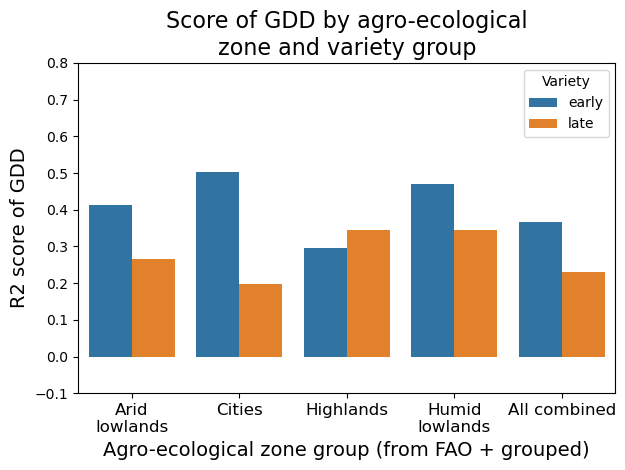

In [74]:
font_size = 14
fig, ax = plt.subplots()
sns.barplot(data = df_pooled_full, hue = 'Variety', x = 'region', y='R2 score', ax=ax)
ax.set_xticks(range(5), ['Arid\nlowlands', 'Cities', 'Highlands', 'Humid\nlowlands', 'All combined'], fontsize =font_size - 2)
ax.set_ylabel('R2 score of GDD', fontsize =font_size)
ax.set_xlabel('Agro-ecological zone group (from FAO + grouped)', fontsize =font_size)
ax.set_title('Score of GDD by agro-ecological\nzone and variety group', fontsize = font_size +2)
ax.set_ylim((-0.1, 0.8))
fig.tight_layout()

In [184]:
df_pooled_full.to_csv('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\results_for_comparing\\TL_tests\\split_varieties_pooled_score_GDD.csv')

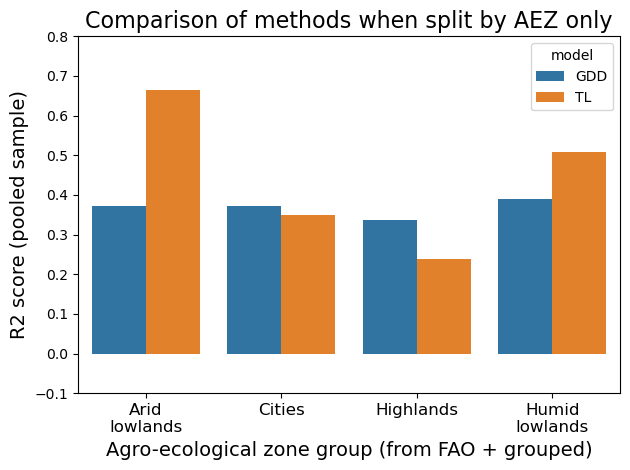

In [73]:
font_size = 14
fig, ax = plt.subplots()
sns.barplot(data = df_pooled_compare, hue = 'model', x = 'region', y='R2 score', ax=ax)
ax.set_xticks(range(4), ['Arid\nlowlands', 'Cities', 'Highlands', 'Humid\nlowlands'], fontsize =font_size - 2)
ax.set_ylabel('R2 score (pooled sample)', fontsize =font_size)
ax.set_xlabel('Agro-ecological zone group (from FAO + grouped)', fontsize =font_size)
ax.set_title('Comparison of methods when split by AEZ only', fontsize = font_size +2)
ax.set_ylim((-0.1, 0.8))
fig.tight_layout()

In [44]:
df_pooled_compare

,Unnamed: 0,R2 score,Variety,model,region
0,0,0.262182,NaN,GDD,NaN
1,1,0.373611,NaN,GDD,NaN
2,2,0.344686,NaN,GDD,NaN
0,0,0.687313,combined,TL,arid low
1,1,0.475974,combined,TL,city
2,2,0.276932,combined,TL,high
3,3,0.554763,combined,TL,humid low


In [69]:
score_dict = results_dict_early
SSE_all_reg = np.array(score_dict['SSEs'])
obsvars_all_reg = np.array(score_dict['observed variances'])
length_all_reg = np.array(score_dict['fold lengths'])
MSE_all_reg = SSE_all_reg.sum(axis=0)/length_all_reg.sum(axis = 0)
R2_all_reg = 1 - (SSE_all_reg/((length_all_reg - 1)*obsvars_all_reg))

In [58]:
early_ds_dict.keys()

dict_keys(['arid low', 'city', 'arid high', 'humid low', 'humid high'])

In [71]:
np.round(R2_all_reg, decimals=2)#.mean(axis=1)

array([[  0.53,   0.33,  -0.78,   0.04,  -0.63],
       [  0.53,   0.8 ,  -0.37,   0.8 ,   0.93],
       [ -0.32,  -0.07,  -0.14,  -0.11, -10.48],
       [  0.48,   0.25,   0.29,   0.4 ,   0.09],
       [  0.05,   0.  ,   0.12,   0.26,   0.32]])

In [72]:
def kfold_df_from_array(array):
    df = pd.DataFrame({'arid lowlands': array[0, :],
                       'arid highlands': array[2, :],
                       'humid lowlands': array[3, :],
                       'humid highlands': array[4, :],
                       'cities': array[1, :]})
    return df

In [73]:
df_early_GDD = kfold_df_from_array(R2_all_reg)

In [74]:
df_early_GDD.to_csv('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\results_for_comparing\\early_vars_split_scores.csv')

(-1.0, 1.0)

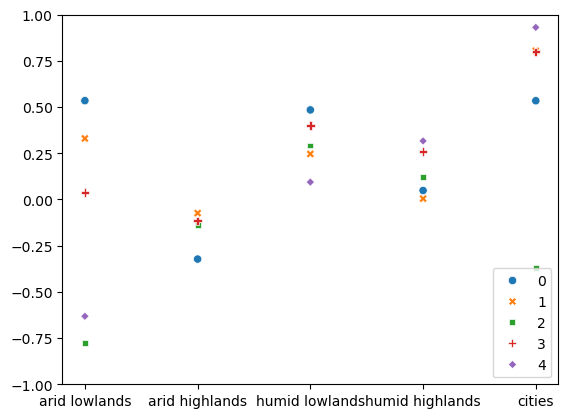

In [76]:
fig, ax =plt.subplots()
sns.scatterplot(data = df_early_GDD.T, ax=ax)
ax.set_ylim((-1, 1))

In [66]:
for method_ind in range(2):
    score_dict = [results_dict_early, results_dict_late][method_ind]
    variety = ['early', 'late'][method_ind]
    TL_method = ['NA', 'NA'][method_ind]
    R2s = skill_score_all_reg(score_dict)
    scores_by_set_method = pd.DataFrame({'Variety': [variety],
                              'TL method': [TL_method],
                              'R2 Fold 1': [R2s[0]],
                              'R2 Fold 2': [R2s[1]],
                              'R2 Fold 3': [R2s[2]],
                              'R2 Fold 4': [R2s[3]],
                              'R2 Fold 5': [R2s[4]]})
    if method_ind == 0:
        scores_full = scores_by_set_method
    else: scores_full = pd.concat((scores_full, scores_by_set_method),axis=0)

In [67]:
scores_full.loc[:, [f'R2 Fold { n + 1}' for n in range(5)]].values.mean(axis=1)

array([0.16689569, 0.11970848])

In [68]:
scores_full

,Variety,TL method,R2 Fold 1,R2 Fold 2,R2 Fold 3,R2 Fold 4,R2 Fold 5
0,early,NA,0.477267,0.346754,-0.043224,0.285039,-0.231358
0,late,NA,0.394753,0.142984,0.327125,-0.145893,-0.120428
